<a href="https://colab.research.google.com/github/Ken-Lau-Lab/single-cell-lectures/blob/main/CCSB_data_club/CCSB_scRNAseq_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demonstration of scRNA-seq basic analyses
- data filtering
- differential gene analysis
- cell type annotation
- pathway analysis

## set up packages

In [ ]:
! pip install  --force-reinstall  gseapy

  Using cached gseapy-1.3.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (13 kB)
  Using cached numpy-2.5.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
ERROR: Operation cancelled by user
^C


In [ ]:
! pip install scanpy pandas numpy==2.4 --force-reinstall

In [ ]:
! pip install anndata

In [ ]:
! pip install leidenalg

In [ ]:
#!pip install POT

In [ ]:
# ! python -m pip install --upgrade pip setuptools wheel

In [1]:
import gseapy as gp

In [2]:
import pandas as pd
import numpy as np
import anndata as ad
from matplotlib import pyplot as plt
import scanpy as sc

## load dataset

In [ ]:
! curl -O -J -L https://www.dropbox.com/scl/fi/t6of2i5osmoxncko4ofvu/s78_post_ambiQuant_dat.h5ad?rlkey=o6cd8of5ycj8kgh5qiptesvti&st=so4objhg&dl=0

In [ ]:
! ls

In [4]:
dat = sc.read("./s78_post_ambiQuant_dat.h5ad")

In [5]:
dat

AnnData object with n_obs × n_vars = 3088 × 23621
    obs: 'total_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_Mitochondrial', 'log1p_total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_ambient', 'log1p_total_counts_ambient', 'pct_counts_ambient'
    var: 'Mitochondrial', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ambient'
    uns: 'Order', 'inflection1', 'inflection_fold'

In [6]:
dat_cut1 = dat.copy() # save the original copy

In [ ]:
# load a function script
! curl -O -J -L https://www.dropbox.com/scl/fi/9jfgyxusbnr30tejtey1q/zc_function.py?rlkey=crqbxejusopkh7u22yad8nzv2&st=2792667w&dl=0

In [ ]:
#del zc

In [13]:
import zc_function as zc

In [ ]:
dir( zc)

## Filter cells

In [ ]:
dat_cut1.X.sum(axis = 1) # check if having raw counts

In [7]:
dat_cut1.raw = dat_cut1.copy()

In [8]:
dat_cut1.layers['raw_counts'] = dat_cut1.X.copy()

In [14]:
zc.normalization( dat_cut1 )

AnnData object with n_obs × n_vars = 3088 × 23621
    obs: 'total_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_Mitochondrial', 'log1p_total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_ambient', 'log1p_total_counts_ambient', 'pct_counts_ambient'
    var: 'Mitochondrial', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ambient', 'mean', 'std'
    uns: 'Order', 'inflection1', 'inflection_fold'
    layers: 'raw_counts', 'arcsinh'

In [15]:
dat_cut1.X.sum(axis = 1) # check if having raw counts

array([ 2715.64  ,  2271.6687,  1596.4993, ..., -1809.635 , -1852.8947,
       -2166.999 ], shape=(3088,), dtype=float32)

In [16]:
zc.clustering( dat_cut1 ) # runs PCA, neighborhood, umap etc

/content/zc_function.py:126: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(dat, return_info=False, use_highly_variable = False )


In [17]:
dat_cut1

AnnData object with n_obs × n_vars = 3088 × 23621
    obs: 'total_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_Mitochondrial', 'log1p_total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_ambient', 'log1p_total_counts_ambient', 'pct_counts_ambient'
    var: 'Mitochondrial', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ambient', 'mean', 'std'
    uns: 'Order', 'inflection1', 'inflection_fold', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw_counts', 'arcsinh'
    obsp: 'distances', 'connectivities'

In [18]:
sc.tl.leiden( dat_cut1)

/tmp/ipykernel_44995/3563037978.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden( dat_cut1)


In [ ]:
qc_strings_no_dropkick = ['total_counts', 'n_genes_by_counts',"pct_counts_in_top_200_genes", 'pct_counts_Mitochondrial', "pct_counts_ambient", 'leiden']
sc.pl.umap( dat_cut1, color= qc_strings_no_dropkick, ncols= 3 )

Leiden cluster 9,2,5,3,1 (10?) seems low quality clusters

In [19]:
dat_cut1.write("./s78_cut1_dat.h5ad")

In [20]:
dat_cut1 = sc.read("./s78_cut1_dat.h5ad")

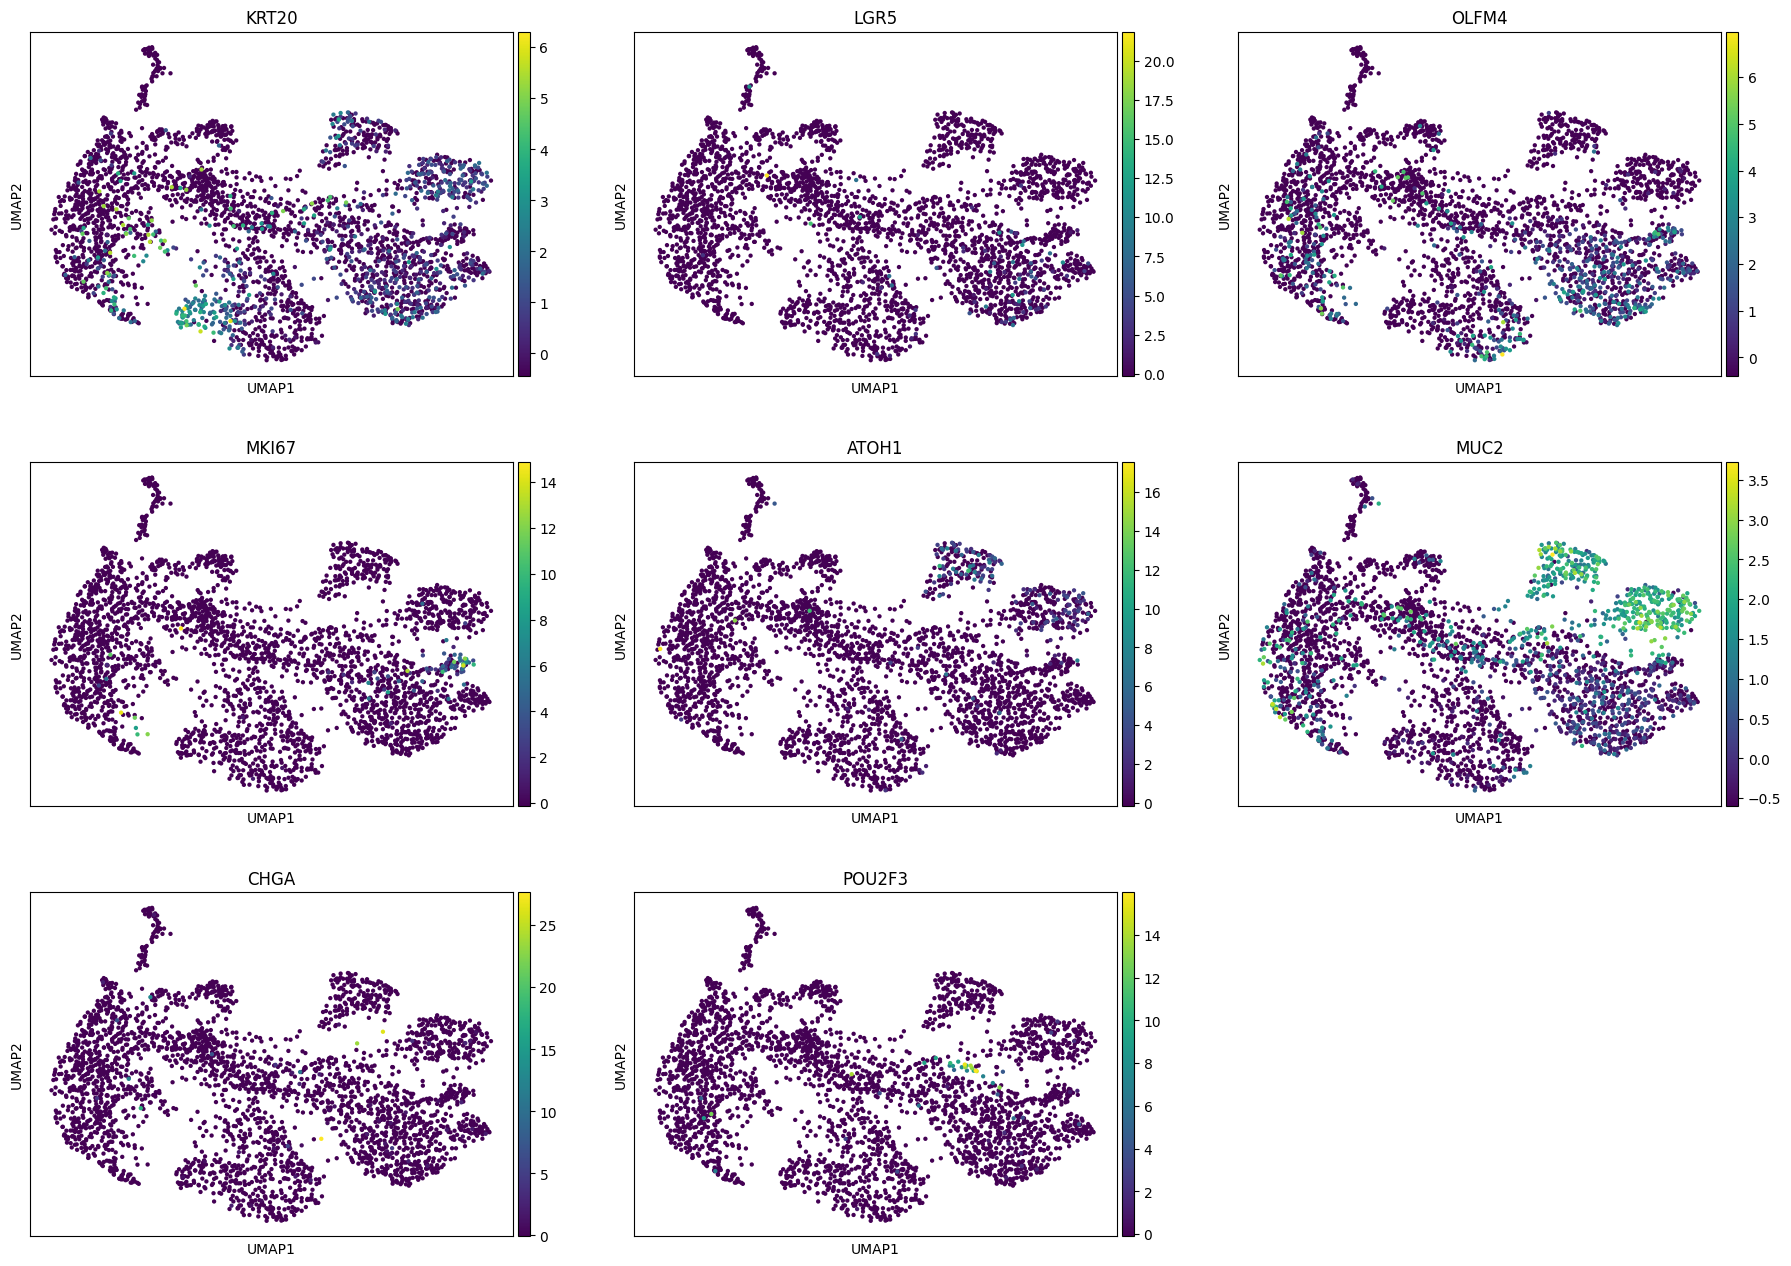

In [21]:
sc.pl.umap( dat_cut1, color= zc.human_classic, ncols= 3, use_raw = False )

In [ ]:
zc.markers_plots_dict( dat_cut1, marker_dict= zc.human_epi, n_cols = 3 )

In [ ]:
zc.markers_plots_dict( dat_cut1, marker_dict= zc.human_nonepi, n_cols = 3 )

In [22]:
# exclude low quality clusters
dat_cut1_filtered = dat_cut1[ np.isin( dat_cut1.obs['leiden'], pd.Series([9,2,5,3,1 ] ).astype( str), invert= True )]

/usr/local/lib/python3.12/dist-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


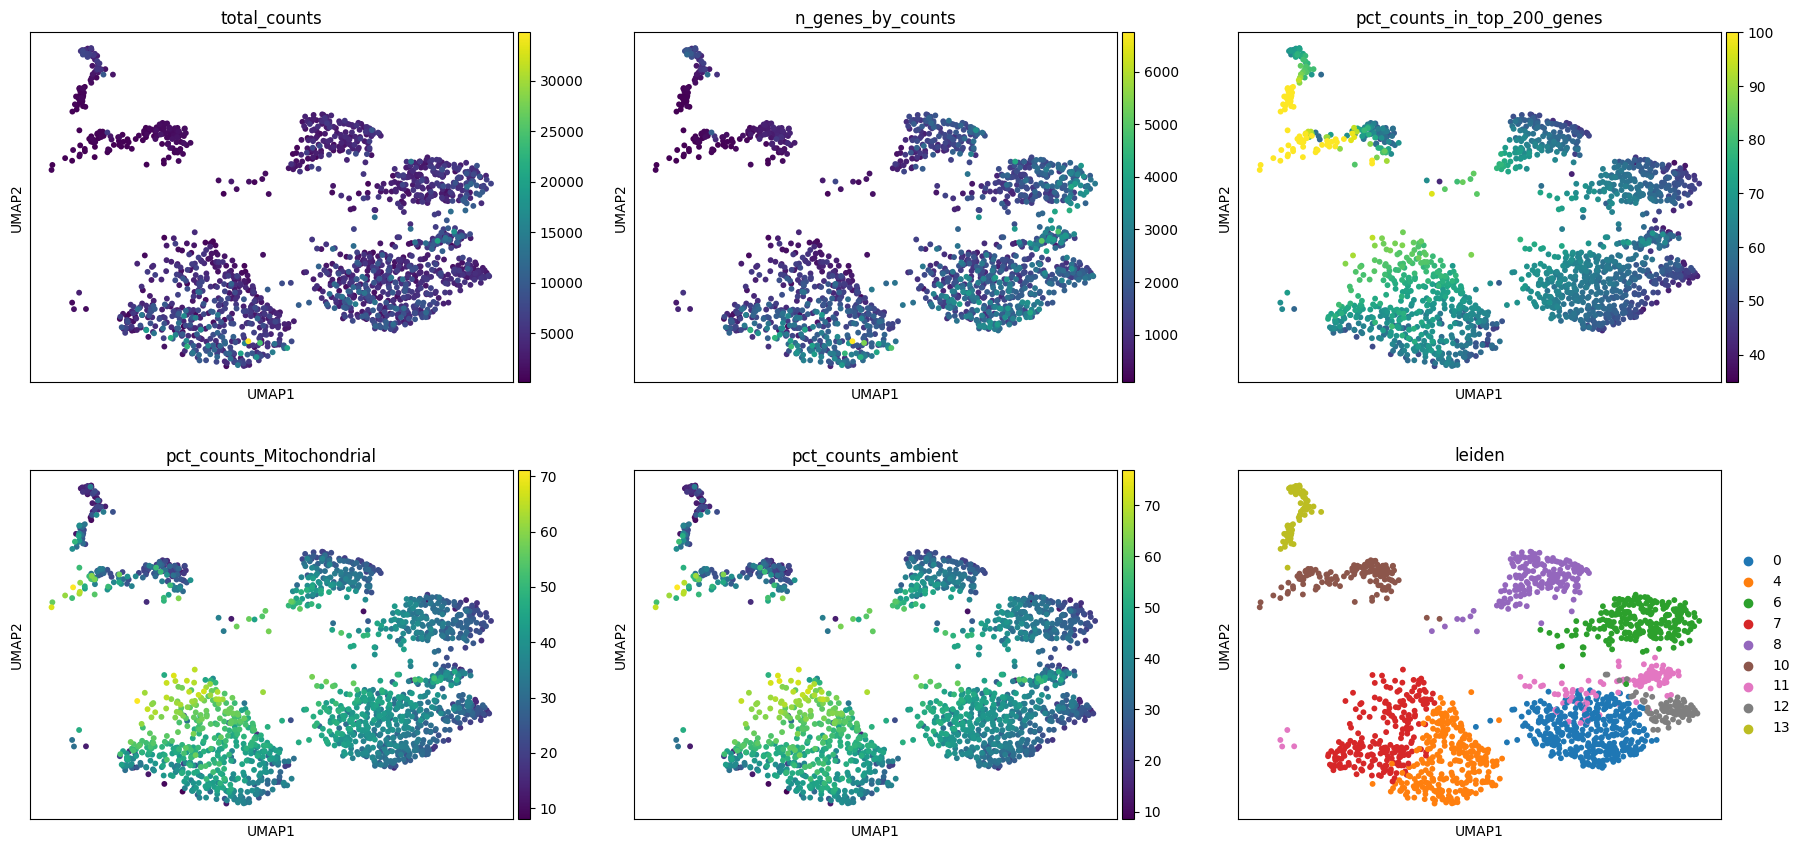

In [23]:
sc.pl.umap( dat_cut1_filtered, color=zc.qc_strings_no_dropkick , ncols=3)

In [24]:
rm_label =  (dat_cut1_filtered.obs['leiden'] == '10') & (dat_cut1_filtered.obs['pct_counts_in_top_200_genes'] > 85 )
rm_label.sum()

np.int64(53)

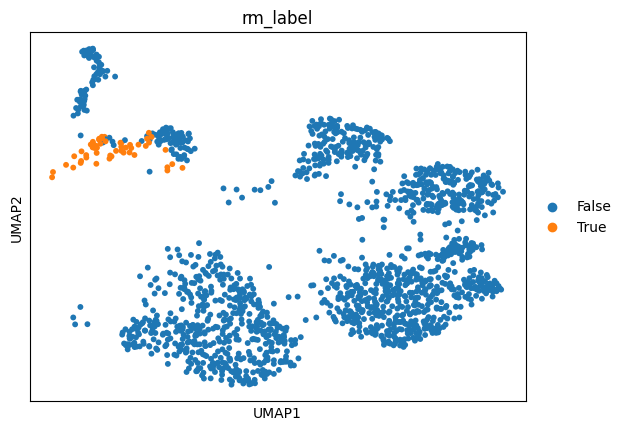

In [25]:
dat_cut1_filtered.obs['rm_label'] = rm_label.astype(str)
sc.pl.umap( dat_cut1_filtered, color= 'rm_label' )

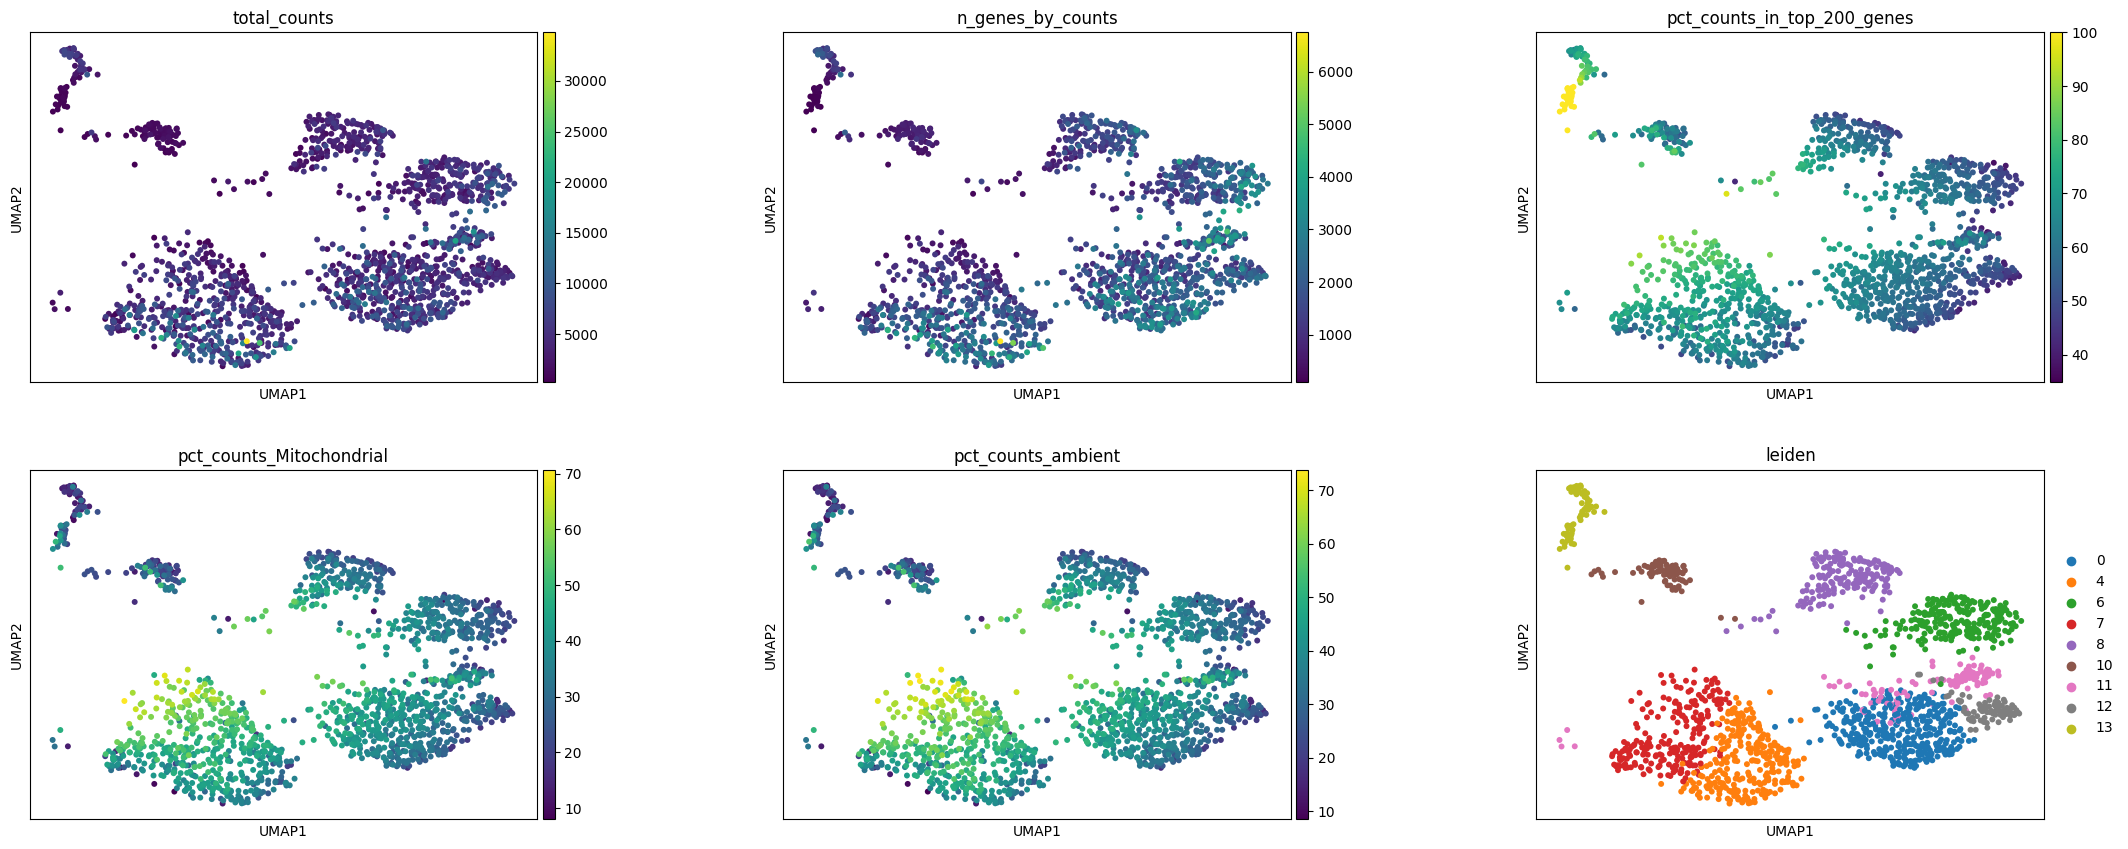

In [26]:
dat_cut1_filtered = dat_cut1_filtered[dat_cut1_filtered.obs['rm_label'] == 'False' ]
sc.pl.umap( dat_cut1_filtered, color=zc.qc_strings_no_dropkick , ncols=3, wspace = 0.35)

In [28]:
dat_cut1_filtered.write("./s78_cut1_filtered.h5ad")

## Check gene expression and perform cell type annotation

In [ ]:
dat_cut1_filtered = sc.read("./s78_cut1_filtered.h5ad")

In [27]:
dat_cut1_filtered.X = dat_cut1_filtered.layers['raw_counts'].copy() # re-cluster

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:639: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_44995/1056623911.py:1: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  dat_cut1_filtered.X = dat_cut1_filtered.layers['raw_counts'].copy() # re-cluster
/tmp/ipykernel_44995/1056623911.py:1: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  dat_cut1_filtered.X = dat_cut1_filtered.layers['raw_counts'].copy() # re-cluster


In [ ]:
zc.normalization( dat_cut1_filtered )

In [ ]:
zc.clustering( dat_cut1_filtered, n_pcs=25 )

In [ ]:
sc.tl.leiden( dat_cut1_filtered , resolution = 0.8)

In [ ]:
sc.pl.umap( dat_cut1_filtered, color = 'leiden')

In [ ]:
sc.pl.umap( dat_cut1_filtered, color= zc.human_classic, ncols= 3, use_raw = False )

In [ ]:
zc.markers_plots_dict( dat_cut1_filtered, marker_dict= zc.human_epi, n_cols = 3 )

In [ ]:
zc.markers_plots_dict( dat_cut1_filtered, marker_dict= zc.human_nonepi, n_cols = 3 )

In [ ]:
# create a new column in the data's obs metadata as for cell type labels
# set default label as UNC ( unclassified)
dat_cut1_filtered.obs['cell_type'] = ['UNC' for i in dat_cut1_filtered.obs.index ]

In [ ]:
dat_cut1_filtered = zc.annotate_clusters( dat_cut1_filtered, from_label=['1'], new_label= 'ABS' )
dat_cut1_filtered = zc.annotate_clusters( dat_cut1_filtered, from_label=['3' ], new_label= 'GOB1' )
dat_cut1_filtered = zc.annotate_clusters( dat_cut1_filtered, from_label=[ '4' ], new_label= 'GOB2' )
dat_cut1_filtered = zc.annotate_clusters( dat_cut1_filtered, from_label=['6'], new_label= 'T' )
dat_cut1_filtered = zc.annotate_clusters( dat_cut1_filtered, from_label=['8'], new_label= 'PLAS' )
dat_cut1_filtered = zc.annotate_clusters( dat_cut1_filtered, from_label=['5'], new_label= 'TAC' )

In [ ]:
sc.pl.umap( dat_cut1_filtered, color = [ 'cell_type', 'leiden'], wspace = 0.4)

- What are the unknown clusters?( leiden 7,0,2 )
- What is the difference between the 2 GOB populations? ( leiden 3,4 )

## Differential gene expression

In [ ]:
dat_cut1_filtered

In [ ]:
dat_cut1_filtered.layers['full_norm'] = dat_cut1_filtered.X.copy() # save the normalized layer

In [ ]:
sc.tl.rank_genes_groups( dat_cut1_filtered, groupby='leiden', use_raw= False, method='wilcoxon', layer= 'arcsinh' , key_added= 'leiden_dge')

In [ ]:
sc.set_figure_params( figsize=[4,4])

In [ ]:
sc.pl.rank_genes_groups( dat_cut1_filtered, key='leiden_dge', sharey= False , ncols=3 )

In [ ]:
dat_cut1_filtered_v2 = dat_cut1_filtered[dat_cut1_filtered.obs['leiden'] != '2']

In [ ]:
dat_cut1_filtered_v2 = zc.annotate_clusters( dat_cut1_filtered_v2, from_label=['0', '7'], new_label= 'Abnormal' )

In [ ]:
# re-grouping to see new cell-type clusters
dat_cut1_filtered_v2.X = dat_cut1_filtered_v2.layers['raw_counts'].copy()
dat_cut1_filtered_v2.X.sum( axis = 1 )

In [ ]:
# save the intermediate result
dat_cut1_filtered_v2.write("./s78_cut1_filtered_v2.h5ad")

In [ ]:
zc.normalization( dat_cut1_filtered_v2 )

In [ ]:
zc.clustering( dat_cut1_filtered_v2 )
sc.pl.umap( dat_cut1_filtered_v2, color = [ 'leiden', 'cell_type'] )

### check cell type specific markers

In [ ]:
sc.tl.rank_genes_groups( dat_cut1_filtered_v2, groupby='cell_type', use_raw= False, method='wilcoxon', layer= 'arcsinh' , key_added= 'cell_type_dge')

In [ ]:
# sc.set_figure_params( figsize=[4,4])

In [ ]:
sc.pl.rank_genes_groups( dat_cut1_filtered_v2, key='cell_type_dge', sharey= False , ncols=3 )

## Pathway analysis
- what are the potential functions for the cell-type specific markers

### check gene set libraries

In [ ]:
# check GSEA libraries
gpl = pd.Series( gp.get_library_name(organism='Human') )
len( gpl)

In [ ]:
gpl[gpl.str.startswith('GO')]

In [ ]:
gpl[gpl.str.startswith('MSig')]

In [ ]:
gpl[gpl.str.startswith('React')]

In [ ]:
gpl[gpl.str.startswith('KEGG')]

In [ ]:
gpl[gpl.str.startswith('Wiki')]

In [ ]:
GENE_SETS = ['GO_Biological_Process_2026', 'MSigDB_Hallmark_2020', 'MSigDB_Oncogenic_Signatures',
             'Reactome_Pathways_2024','KEGG_2026', 'WikiPathways_2024_Human' ]

### Prerank
- given a list of ranked genes for the cell type, which pathway's genes rank higher within the cell type's ranked gene list

In [ ]:
dge_df_dict = dict()
cell_types = dat_cut1_filtered_v2.obs['cell_type'].unique()

for c in cell_types:
    df = zc.parse_rank_gene_group_dict( dat_cut1_filtered_v2.uns['cell_type_dge'], condition=c, )
    dge_df_dict[c] = df

In [ ]:
dge_df_dict['GOB1'].head()

In [ ]:
# get a ranked list composed of a gene name and a rank score column
df = dge_df_dict['GOB1'].copy()
df = df.reset_index().rename(columns={'names': "gene"})

# clean the df
ranked = (
        df.loc[:, ["gene",'scores', 'logfoldchanges', 'pvals_adj']]
          .dropna( how = 'any')
          .copy()
    )

# sort the df by score
ranked = (
        ranked.sort_values('scores', ascending=False)
              .drop_duplicates(subset="gene", keep="first")
    )

# exclude irrelevant columns
rnk = ranked.loc[:, ["gene",'scores']].sort_values('scores', ascending=False)

In [ ]:
ascending = False
threads = 16

pre_res = gp.prerank(
    rnk=rnk,
    gene_sets= GENE_SETS[0] ,   # replace with your library or GMT
    permutation_num=1000,
    min_size=15,
    max_size=500,
    seed=42,
    verbose=True,
    threads = threads,
    ascending = ascending,
)

In [ ]:
pre_res.res2d.sort_values( by = 'NES', ascending = False).head()

In [ ]:
# plot top enriched terms
res_obj = pre_res
res_obj_df = pre_res.res2d # the result from GOB1

# some parameters
sort_by = 'NES'
ascending = False
n_terms = 5

top_res_df = res_obj_df.copy()
top_res_df = top_res_df[ top_res_df[ 'NOM p-val' ] < 0.05 ] # filter based on significance
print( top_res_df.shape) # number of significant terms

top_res = top_res_df.sort_values( by = sort_by, ascending= ascending ).head(min(top_res_df.shape[0], n_terms))

for t in top_res.index:
    axs = res_obj.plot(terms= top_res_df.loc[t, 'Term'] )
    plt.show()

In [ ]:
gp.barplot(
    res_obj_df,
    column='NES',
    title='GO Biological Process',
    top_term=10,
    figsize=(5,6)
)
plt.show()


### Enrichment
- given a list of top markers, which pathway contains more of the markers

In [ ]:
# extract top differential genes
top_enriched_genes = zc.get_up_down_dge_from_rankGenDict( dat_cut1_filtered_v2, 'cell_type_dge', group_by='cell_type')

In [ ]:
top_enriched_genes.head()

In [ ]:
top_enriched_genes['GOB1_up']

In [ ]:
gob1_enr = gp.enrichr( top_enriched_genes['GOB1_up'], gene_sets = GENE_SETS, )

In [ ]:
res_df = gob1_enr.res2d
res_df.shape

In [ ]:
res_df.head(2 )

In [ ]:
res_df2 = res_df[res_df['Adjusted P-value'] < 0.05 ]
res_df2.shape

In [ ]:
res_df2.sort_values( by = 'Combined Score', ascending= False).head()

In [ ]:
gp.barplot(
    gob1_enr.res2d,
    column='Combined Score',
    title='GO Biological Process',
    top_term=10,
    figsize=(5,6)
)
plt.show()
